# Representation geometry of compiled RASP programs

Analyze the twelve programs and focused A/B examples using balanced target
observations, PCA spectra, participation ratios, and linear CKA. Numerical
methods live in `raspformer/geometry.py`; configuration and plots stay here.

This is a descriptive study of compiled models. Full versus computed lanes
is a representation view comparison, not a retraining ablation.

In [1]:
import os
from pathlib import Path

start = Path.cwd().resolve()
PROJECT_ROOT = next(
    root
    for root in (start, *start.parents)
    if (root / "raspformer").is_dir() and (root / "notebooks").is_dir()
)
os.chdir(PROJECT_ROOT)

%matplotlib inline
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from raspformer.compiler import CompilerConfig
from raspformer.geometry import (
    ProbeConfig,
    lane_variances,
    pca_coordinates,
    representation,
    run_geometry_study,
    trajectory_coordinates,
)
from raspformer.programs import build_programs

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

Matplotlib is building the font cache; this may take a moment.


## Configure the study

Preserve seed 42, length 6, and 64 observations per reachable output class.
Classes are balanced separately for each program, then stratified across
reachable positions. Repeated samples retain their weight. Each activation
row represents one target token; BOS and PAD are excluded.

In [2]:
compiler_config = CompilerConfig(
    vocab=tuple(range(-2, 6)),
    max_seq_len=6,
    causal=False,
    bos="BOS",
    pad="PAD",
    mlp_exactness=100,
    rel_tol=1e-4,
    abs_tol=1e-4,
)
probe_config = ProbeConfig(
    seed=42,
    length=6,
    samples_per_class=64,
    random_candidates=2048,
    structured_candidates=128,
)
OUTPUT_ROOT = PROJECT_ROOT / "results" / "geometry"
FOCUSED_PROGRAMS = (
    "A_prev_token_class",
    "B_histogram_then_repeated_class",
    "P11_check_palindrome",
)
PROGRAMS = build_programs(compiler_config.max_seq_len, include_examples=True)

## Collect and analyze

All compiled target outputs must match RASP before analysis. PCA uses global
feature centering with no whitening; CKA compares the same ordered targets
across stages within a program. Zero variance gives zero PCA spectrum/PR
and undefined CKA. Different programs have separate probe samples.

In [3]:
result = run_geometry_study(PROGRAMS, compiler_config, probe_config, OUTPUT_ROOT)
probes = result["probes"]
activations = result["activations"]
analysis = result["analysis"]
RUN_DIR = result["run_dir"]
FIGURE_DIR = RUN_DIR / "figures"
FIGURE_DIR.mkdir()
display(probes.audit)
print(f"Candidate pool: {len(probes.candidates)} unique sequences")
print(f"Saved measurements: {RUN_DIR}")

P01_absolute: 6 classes × 64 targets
P02_index_parity: 2 classes × 64 targets
P03_increment_by_index: 13 classes × 64 targets
P04_first_element: 8 classes × 64 targets
P05_histogram: 6 classes × 64 targets
P06_count_greater_than: 6 classes × 64 targets
P07_sum_with_next: 15 classes × 64 targets
P08_pairwise_sum: 15 classes × 64 targets


P09_check_increasing: 2 classes × 64 targets
P10_rotate_left: 8 classes × 64 targets
P11_check_palindrome: 2 classes × 64 targets
P12_sorting: 8 classes × 64 targets


A_prev_token_class: 8 classes × 64 targets
B_histogram_then_repeated_class: 2 classes × 64 targets


P01_absolute: 3 stages; width=22; 1.1s


P02_index_parity: 3 stages; width=19; 0.7s


...

P11_check_palindrome: 13 stages; width=69; 1.0s


P12_sorting: 7 stages; width=81; 1.0s
A_prev_token_class: 3 stages; width=25; 0.1s


B_histogram_then_repeated_class: 5 stages; width=27; 1.1s
P01_absolute: PCA and all stage-pair CKA complete
P02_index_parity: PCA and all stage-pair CKA complete
P03_increment_by_index: PCA and all stage-pair CKA complete
P04_first_element: PCA and all stage-pair CKA complete
P05_histogram: PCA and all stage-pair CKA complete
P06_count_greater_than: PCA and all stage-pair CKA complete
P07_sum_with_next: PCA and all stage-pair CKA complete
P08_pairwise_sum: PCA and all stage-pair CKA complete
P09_check_increasing: PCA and all stage-pair CKA complete
P10_rotate_left: PCA and all stage-pair CKA complete
P11_check_palindrome: PCA and all stage-pair CKA complete
P12_sorting: PCA and all stage-pair CKA complete
A_prev_token_class: PCA and all stage-pair CKA complete
B_histogram_then_repeated_class: PCA and all stage-pair CKA complete


,program,output_class,observations,unique_sequences,unique_targets
0,P01_absolute,0,64,64,64
1,P01_absolute,1,64,64,64
2,P01_absolute,2,64,62,64
3,P01_absolute,3,64,63,64
4,P01_absolute,4,64,62,64
...,...,...,...,...,...
96,A_prev_token_class,3,64,64,64
97,A_prev_token_class,4,64,63,64
98,A_prev_token_class,5,64,63,64
99,B_histogram_then_repeated_class,0,64,62,64


Candidate pool: 3383 unique sequences
Saved measurements: /Users/raghul/RaspFormer/results/geometry/output_balanced_L6_seed42_n64_20261006T062123_fdb3cf7a


## Audit class and position balance

Green bars show decoded model outputs; blue bars show RASP targets. Their
agreement is checked numerically by the study runner.

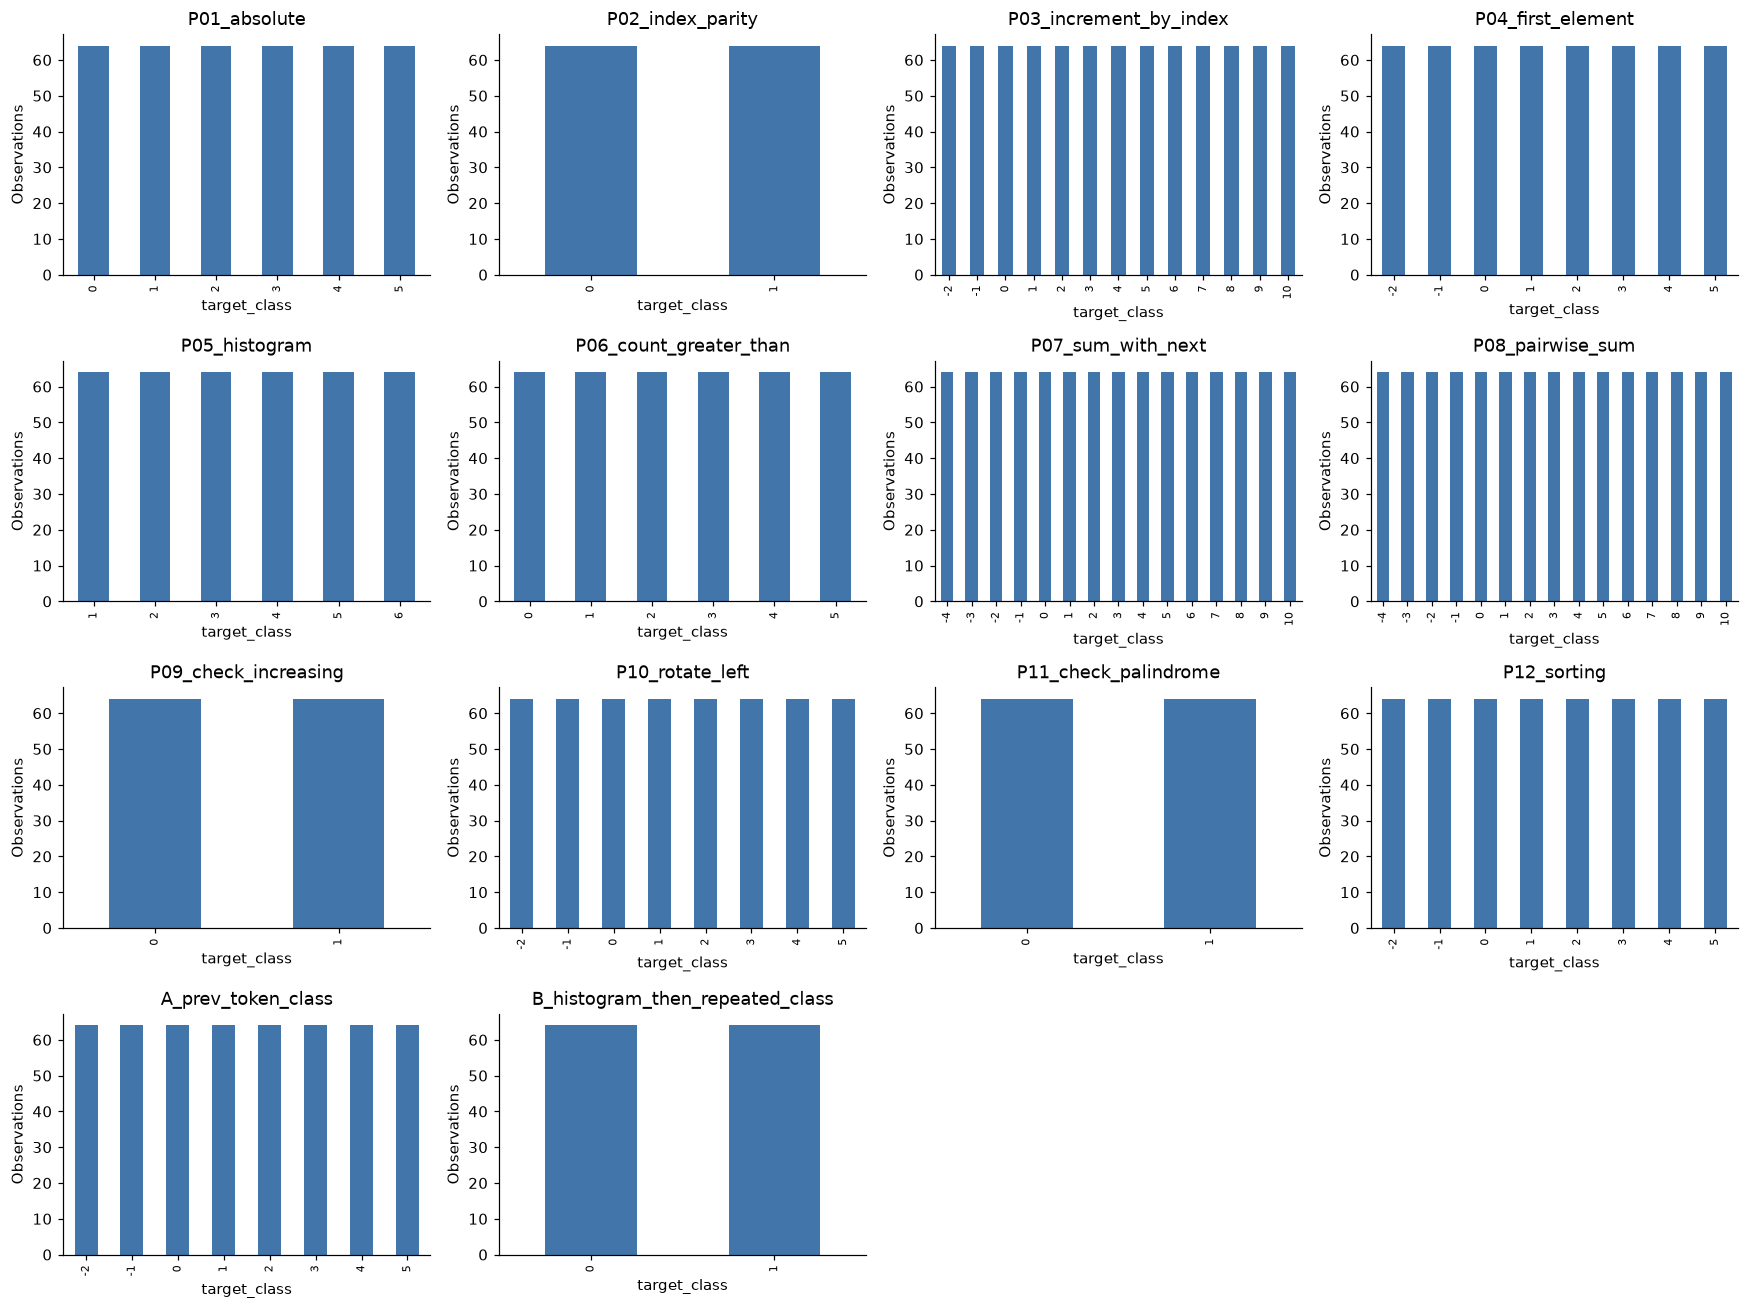

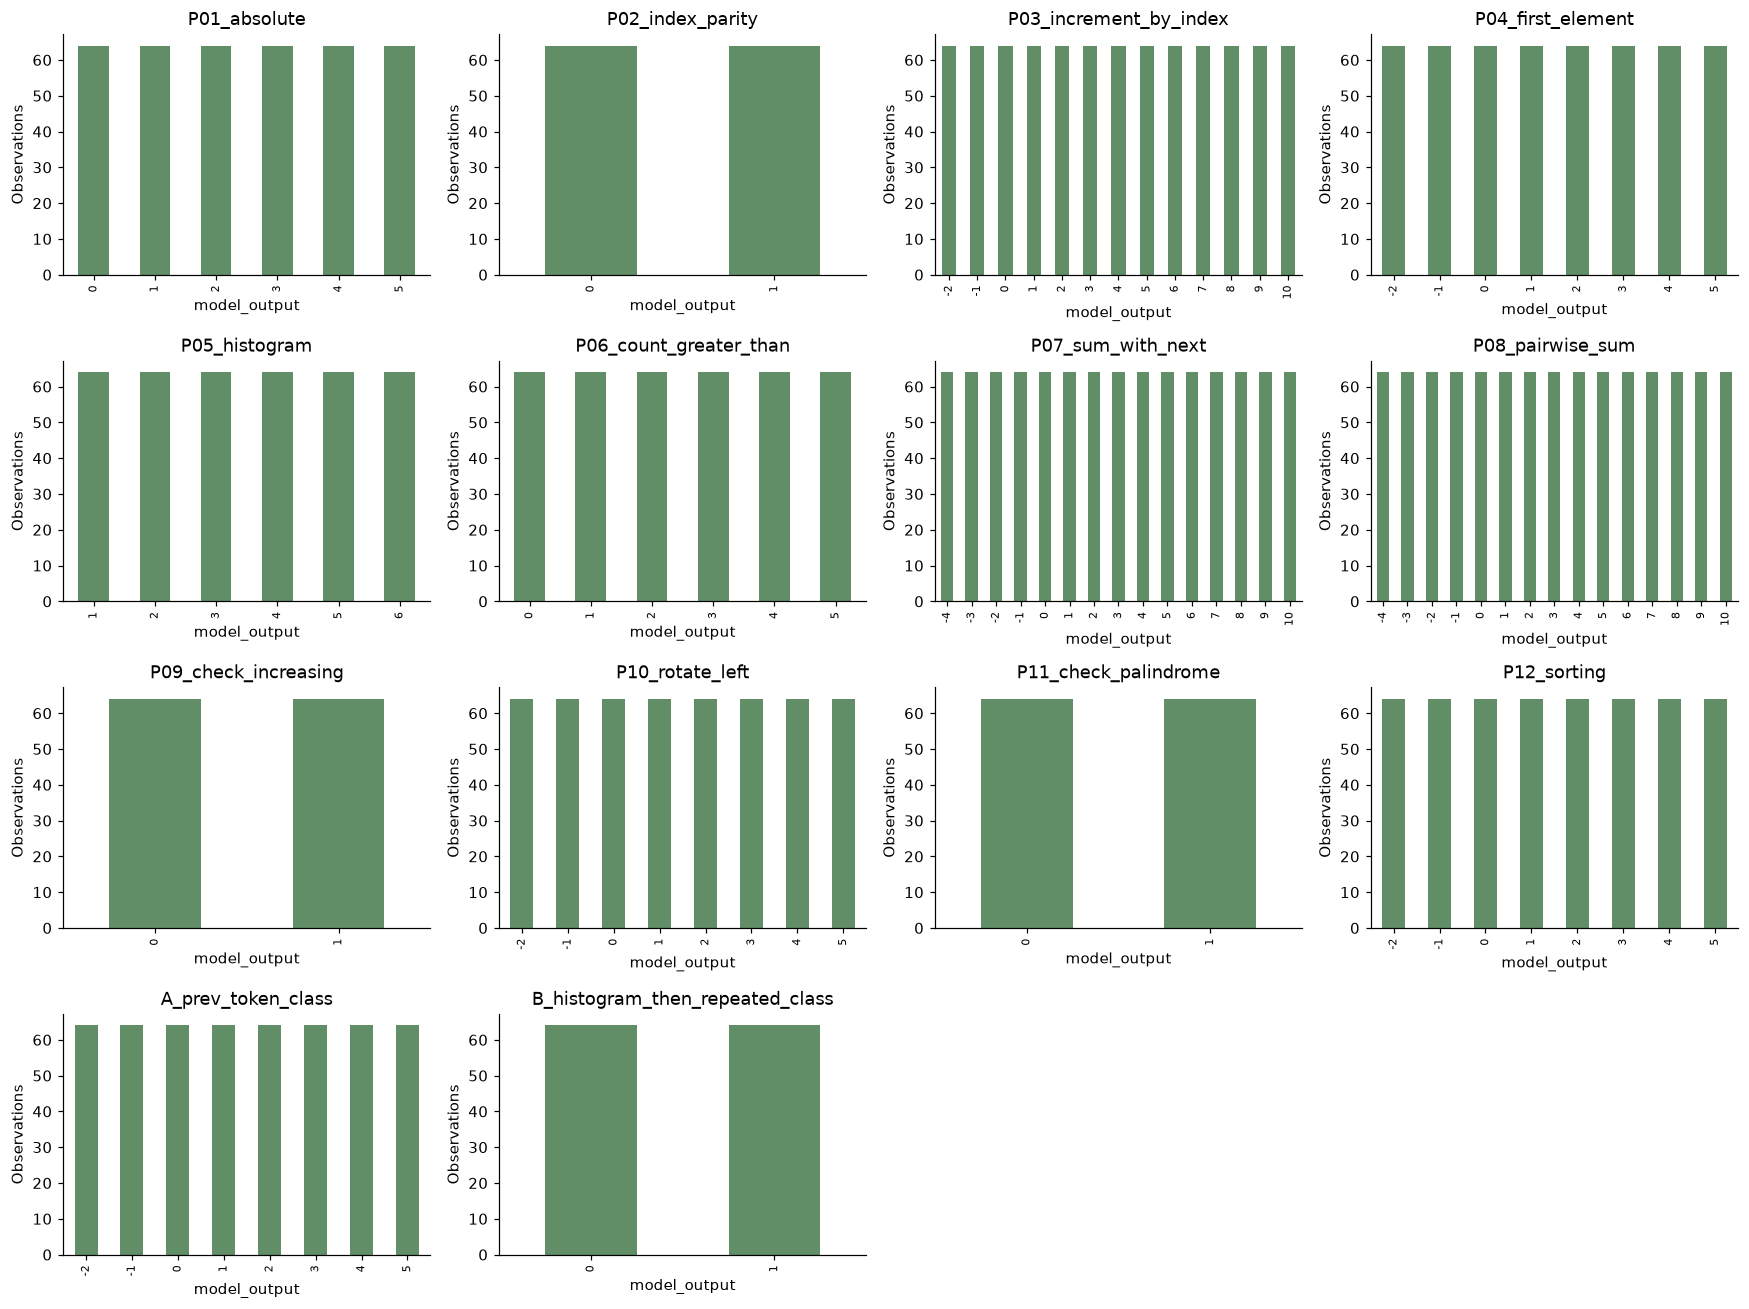

In [4]:
def distribution_grid(tables, column, color, filename, figure_dir):
    rows = (len(tables) + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(16, 3 * rows), squeeze=False)
    for ax, (name, table) in zip(axes.flat, tables.items()):
        table[column].value_counts().sort_index().plot.bar(ax=ax, color=color)
        ax.set(title=name, xlabel=column, ylabel="Observations")
        ax.tick_params(axis="x", labelsize=7)
    for ax in list(axes.flat)[len(tables) :]:
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(figure_dir / filename, bbox_inches="tight")
    plt.show()


distribution_grid(
    probes.observations,
    "target_class",
    "#4276ab",
    "output_class_balance.png",
    FIGURE_DIR,
)
distribution_grid(
    activations.observations,
    "model_output",
    "#628e67",
    "output_distributions.png",
    FIGURE_DIR,
)

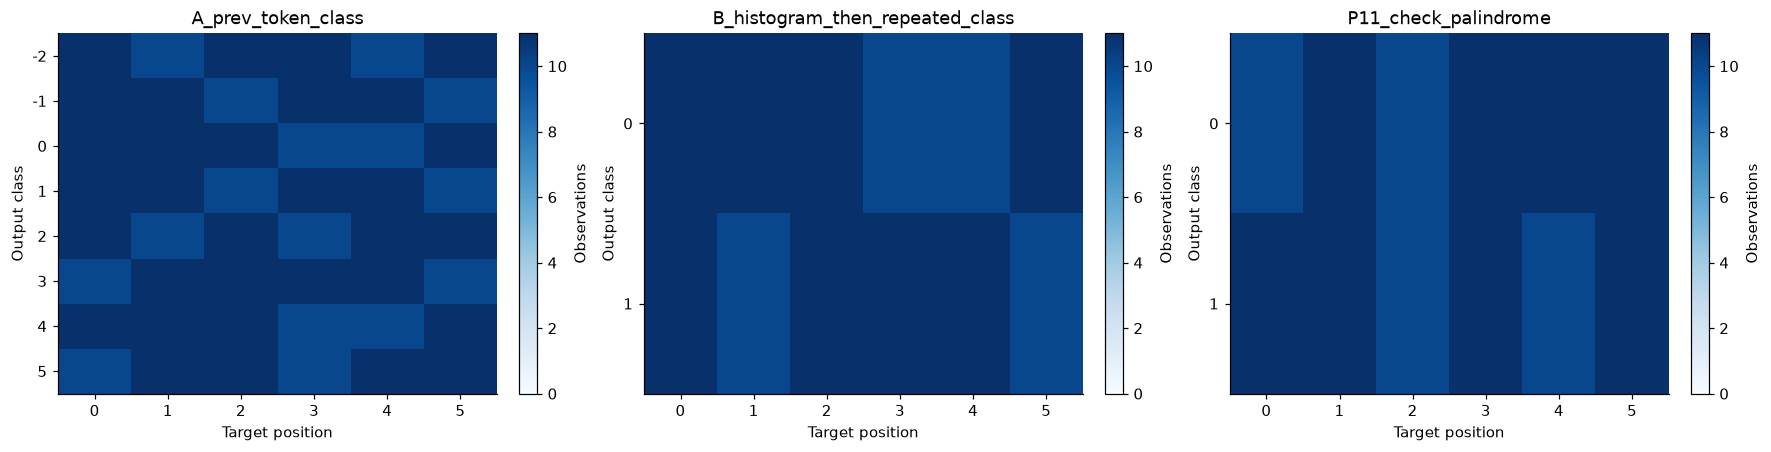

In [5]:
fig, axes = plt.subplots(
    1, len(FOCUSED_PROGRAMS), figsize=(16, 4), constrained_layout=True
)
for ax, name in zip(axes, FOCUSED_PROGRAMS):
    table = probes.observations[name]
    counts = pd.crosstab(table.target_class, table.position).reindex(
        columns=range(probe_config.length),
        fill_value=0,
    )
    image = ax.imshow(counts.to_numpy(), aspect="auto", cmap="Blues", vmin=0)
    ax.set(
        title=name,
        xticks=range(probe_config.length),
        xlabel="Target position",
        yticks=range(len(counts)),
        yticklabels=counts.index,
        ylabel="Output class",
    )
    fig.colorbar(image, ax=ax, label="Observations")
fig.savefig(FIGURE_DIR / "class_position_balance.png", bbox_inches="tight")
plt.show()

## Compare effective dimensions and stage similarity

The computed view excludes token, index, and constant-one input lanes.
Participation ratio summarizes the PCA spectrum; `pc95` is the number of
components accounting for 95% of total variance. Gray CKA cells are undefined.

In [6]:
metrics = analysis.metrics
full_layers = metrics[
    (metrics.stage == "Embedding") | metrics.stage.str.endswith("/MLP")
]
display(
    full_layers[full_layers.view == "full"]
    .pivot(
        index="program",
        columns="stage",
        values="participation_ratio",
    )
    .round(3)
)

stage,Embedding,L1/MLP,L2/MLP,L3/MLP,L4/MLP,L5/MLP,L6/MLP
program,,,,,,,
A_prev_token_class,11.618,17.513,NaN,NaN,NaN,NaN,NaN
B_histogram_then_repeated_class,10.930,12.857,7.990,NaN,NaN,NaN,NaN
P01_absolute,11.184,10.184,NaN,NaN,NaN,NaN,NaN
P02_index_parity,11.154,7.140,NaN,NaN,NaN,NaN,NaN
P03_increment_by_index,10.663,16.611,NaN,NaN,NaN,NaN,NaN
P04_first_element,11.614,17.744,NaN,NaN,NaN,NaN,NaN
P05_histogram,11.511,16.276,NaN,NaN,NaN,NaN,NaN
P06_count_greater_than,11.365,14.413,NaN,NaN,NaN,NaN,NaN
P07_sum_with_next,11.274,11.274,8.916,19.120,NaN,NaN,NaN


In [7]:
def cka_image(ax, matrix, labels, title):
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("#dedede")
    image = ax.imshow(np.ma.masked_invalid(matrix), vmin=0, vmax=1, cmap=cmap)
    ax.set(
        xticks=range(len(labels)),
        yticks=range(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        title=title,
    )
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    return image


def dashboard(data, profiles, program, view="full", stage=None, color="model_output"):
    profile = profiles[program][view]
    stages = list(profile["pca"])
    stage = stage or stages[-1]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    for label, line_color in zip(
        stages, plt.cm.viridis(np.linspace(0.1, 0.9, len(stages)))
    ):
        ratio = profile["pca"][label]["explained_variance_ratio"]
        pc = np.arange(1, len(ratio) + 1)
        positive = ratio > 0
        axes[0, 0].semilogy(
            pc[positive], ratio[positive], color=line_color, label=label
        )
        axes[0, 1].plot(pc, np.cumsum(ratio), color=line_color)
    axes[0, 0].set(
        title="PCA spectrum", xlabel="Principal component", ylabel="Variance fraction"
    )
    axes[0, 0].legend(fontsize=7, ncol=2)
    axes[0, 1].axhline(0.95, color="gray", ls="--")
    axes[0, 1].set(
        title="Cumulative variance",
        xlabel="Components",
        ylabel="Variance fraction",
        ylim=(0, 1.03),
    )
    for field, marker, label in (
        ("participation_ratio", "o-", "Participation ratio"),
        ("pc95", "s--", "PCs for 95% variance"),
    ):
        axes[0, 2].plot(
            stages,
            [profile["pca"][label][field] for label in stages],
            marker,
            label=label,
        )
    axes[0, 2].set(title="Effective dimensionality", ylabel="Dimensions")
    axes[0, 2].tick_params(axis="x", rotation=60, labelsize=8)
    axes[0, 2].legend(fontsize=8)
    image = cka_image(
        axes[1, 0], profile["cka"], stages, "Linear CKA: every stage pair"
    )
    fig.colorbar(image, ax=axes[1, 0], fraction=0.046)
    spectra = np.stack(
        [profile["pca"][label]["explained_variance_ratio"] for label in stages]
    )
    image = axes[1, 1].imshow(spectra, aspect="auto", cmap="magma")
    axes[1, 1].set(
        title="Spectrum across stages",
        xlabel="PC index (zero based)",
        yticks=range(len(stages)),
        yticklabels=stages,
    )
    fig.colorbar(image, ax=axes[1, 1], fraction=0.046, label="Variance fraction")
    selected = profile["pca"][stage]
    ax = axes[1, 2]
    if selected["total_variance"] == 0:
        ax.text(
            0.5,
            0.5,
            "This stage has zero variance",
            ha="center",
            transform=ax.transAxes,
        )
        ax.set(title=f"PCA scatter: {stage}")
    else:
        points = pca_coordinates(representation(data, program, view, stage), selected)
        codes, categories = pd.factorize(data.observations[program][color], sort=True)
        image = ax.scatter(
            points[:, 0], points[:, 1], c=codes, cmap="tab20", s=12, alpha=0.55
        )
        bar = fig.colorbar(image, ax=ax, fraction=0.046, ticks=range(len(categories)))
        bar.ax.set_yticklabels([str(value) for value in categories])
        bar.set_label(color)
        ratio = np.pad(
            selected["explained_variance_ratio"],
            (0, max(0, 2 - len(selected["eigenvalues"]))),
        )
        ax.set(
            title=f"PCA scatter: {stage}",
            xlabel=f"PC1 ({ratio[0]:.1%})",
            ylabel=f"PC2 ({ratio[1]:.1%})",
        )
    fig.suptitle(
        f"{program} | {view} | {len(data.observations[program])} balanced targets",
        fontsize=15,
    )
    return fig

## Inspect a program

This static example is also saved below. The controls update the dashboard
after execution in Jupyter; changing the program refreshes available stages.

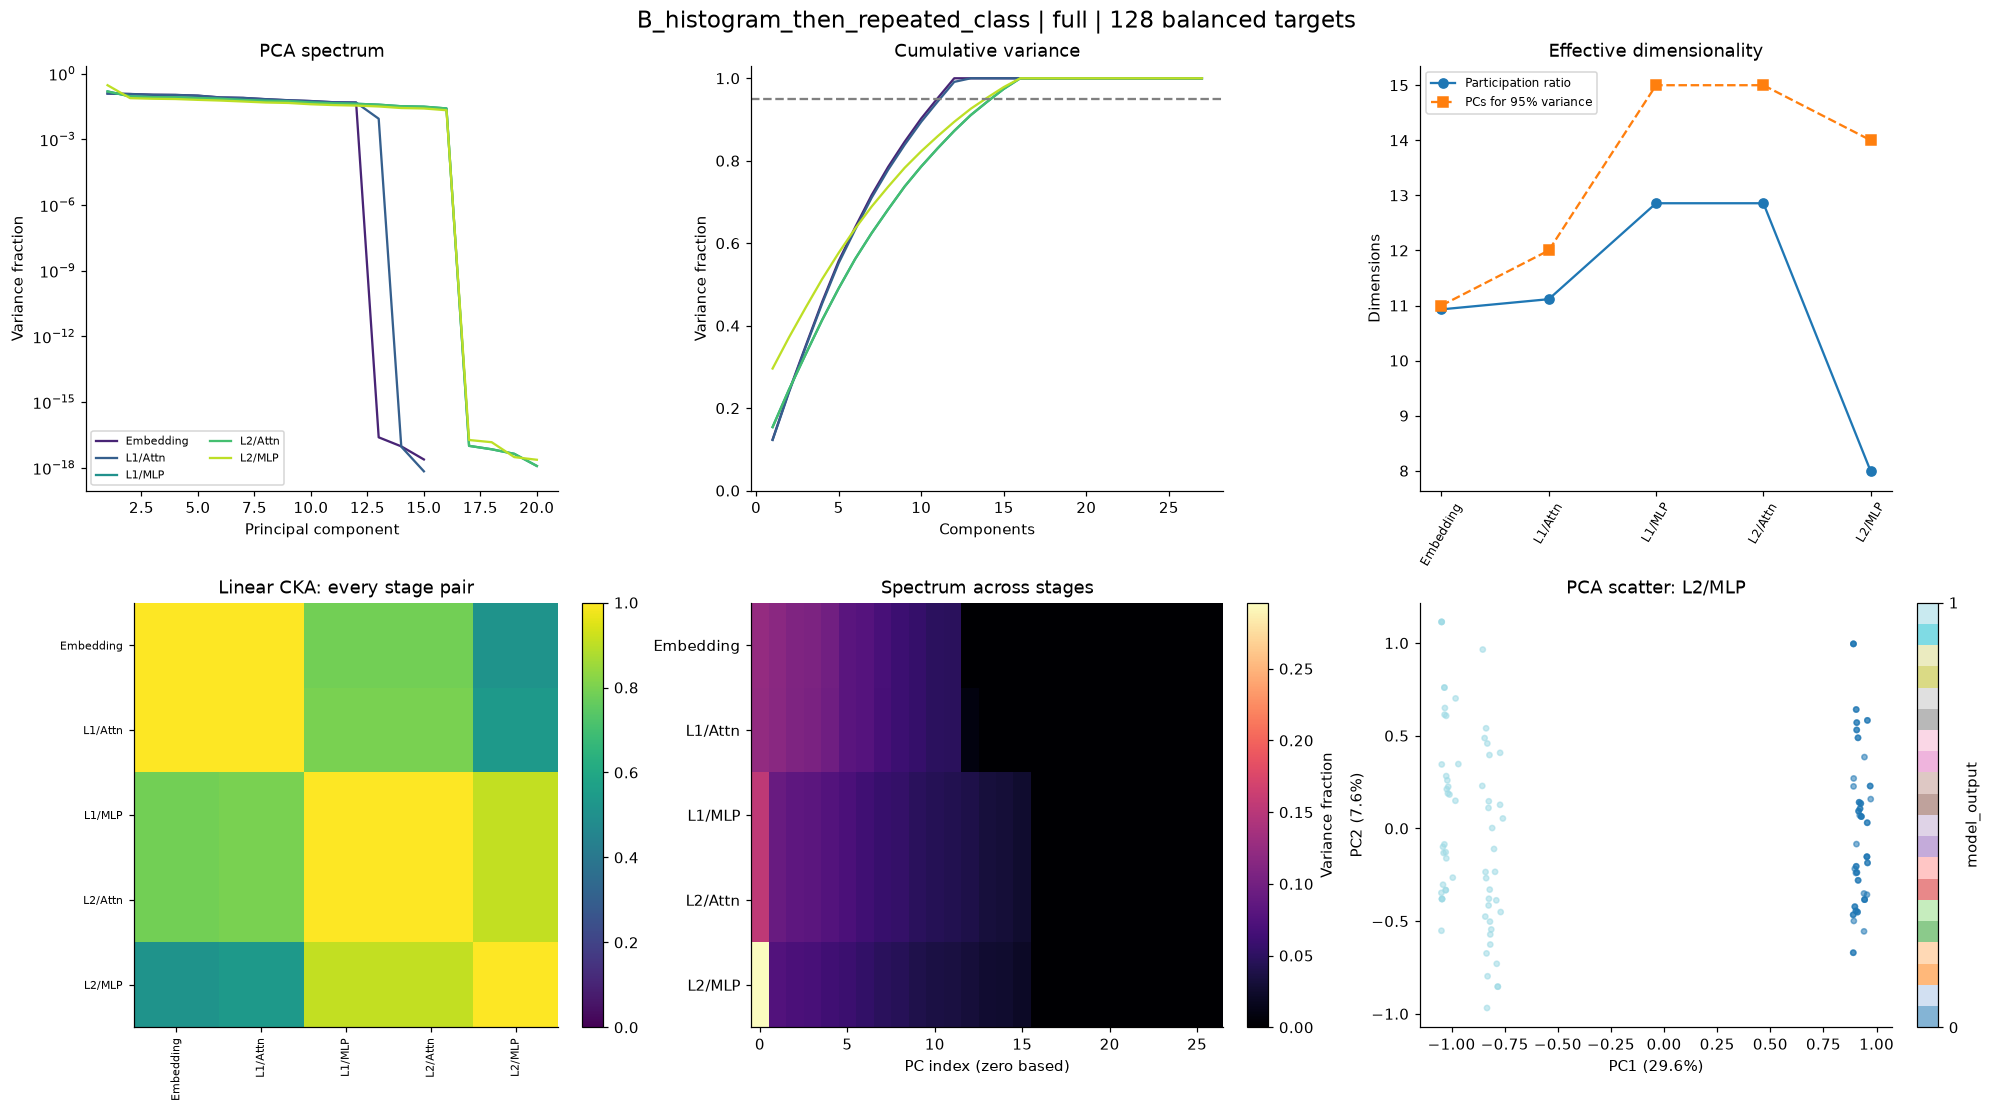

In [8]:
fig = dashboard(activations, analysis.profiles, "B_histogram_then_repeated_class")
plt.show()

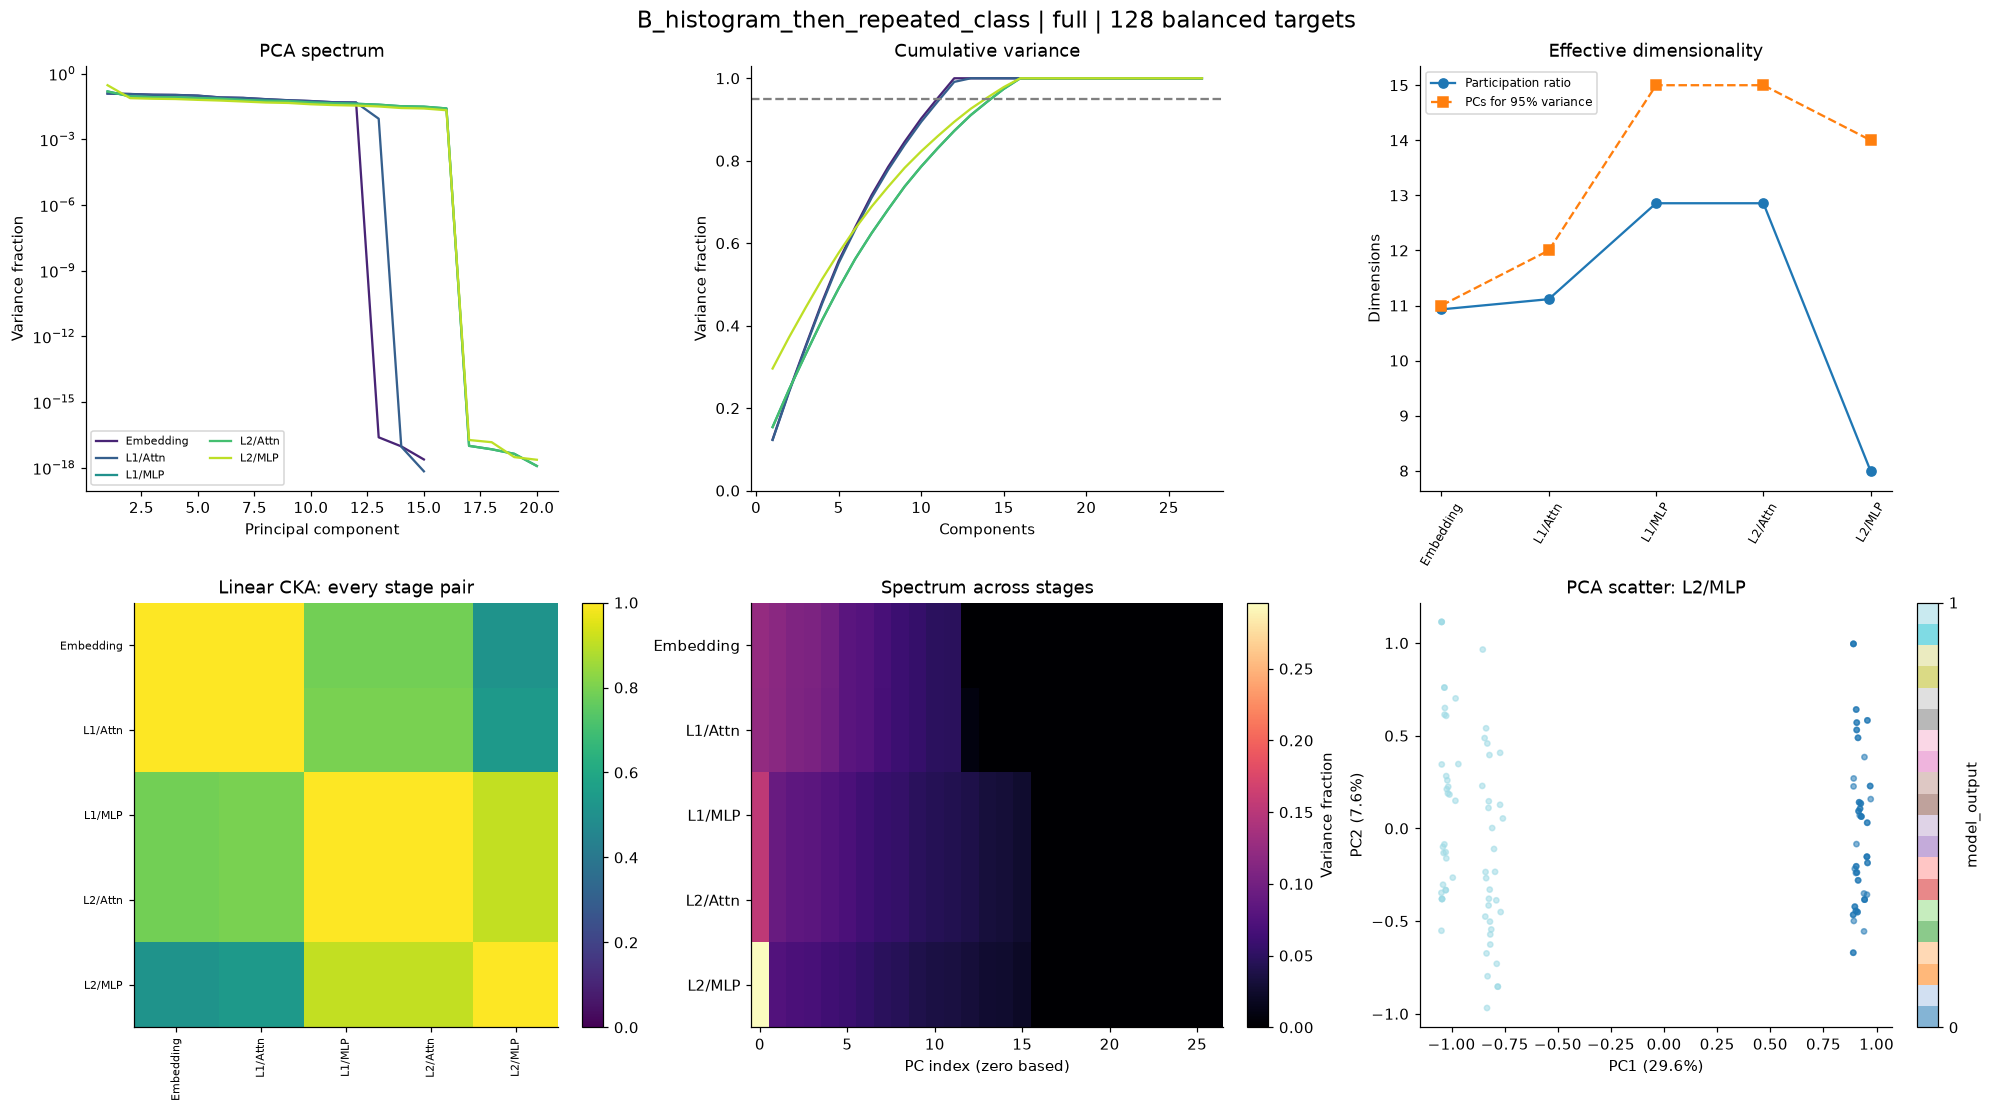

In [9]:
program_widget = widgets.Dropdown(
    options=list(PROGRAMS),
    value="B_histogram_then_repeated_class",
    description="Program:",
    layout=widgets.Layout(width="450px"),
)
view_widget = widgets.Dropdown(options=["full", "computed"], description="View:")
stage_widget = widgets.Dropdown(
    options=list(activations.stages[program_widget.value]), description="Stage:"
)
stage_widget.value = stage_widget.options[-1]
color_widget = widgets.Dropdown(
    options=["model_output", "token", "position", "family"], description="Color:"
)


def update_stages(change):
    stage_widget.options = list(activations.stages[change["new"]])
    stage_widget.value = stage_widget.options[-1]


def show_dashboard(program, view, stage, color):
    dashboard(activations, analysis.profiles, program, view, stage, color)
    plt.show()


program_widget.observe(update_stages, names="value")
output = widgets.interactive_output(
    show_dashboard,
    {
        "program": program_widget,
        "view": view_widget,
        "stage": stage_widget,
        "color": color_widget,
    },
)
display(
    widgets.VBox(
        [
            widgets.HBox([program_widget, view_widget]),
            widgets.HBox([stage_widget, color_widget]),
            output,
        ]
    )
)

## All-program comparisons

Keep the layer order numeric. Missing layers and zero-variance comparisons
appear in gray; they are not zero-valued measurements.

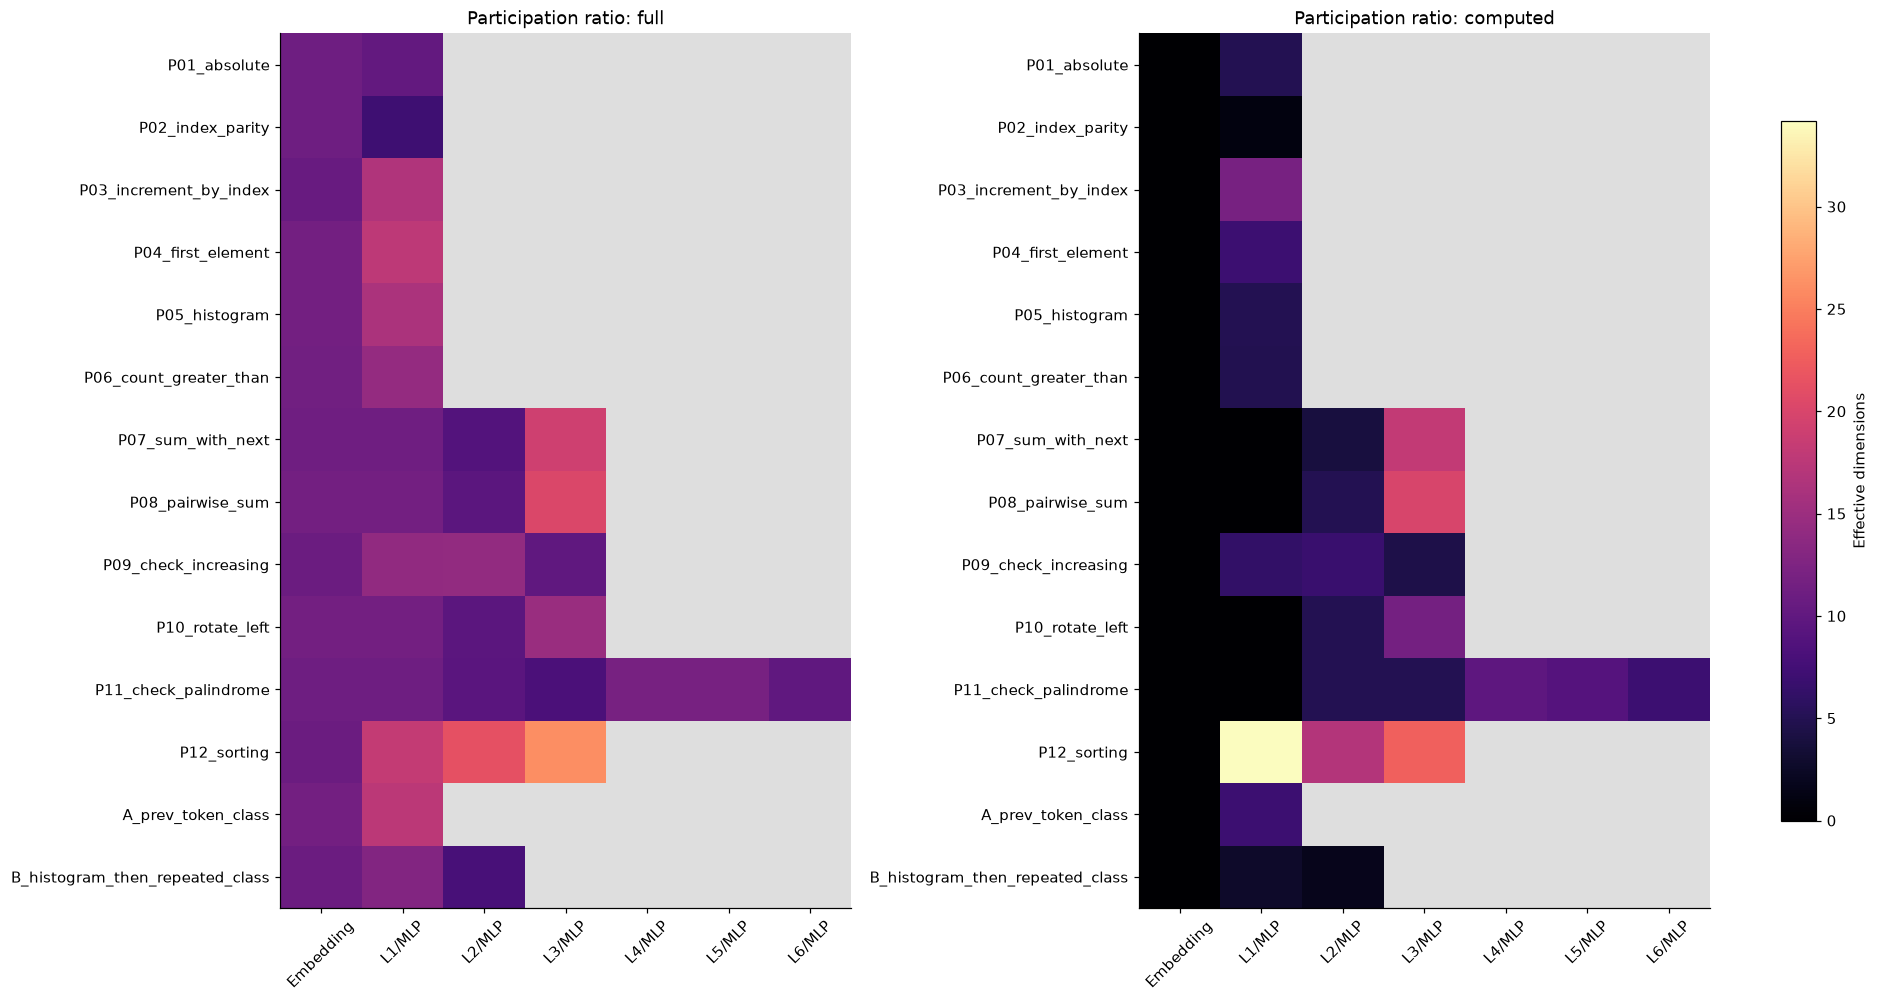

In [10]:
max_layers = max(model.model_config.num_layers for model in activations.models.values())
layer_labels = ["Embedding"] + [f"L{index}/MLP" for index in range(1, max_layers + 1)]
tables = {
    view: full_layers[full_layers.view == view]
    .pivot(
        index="program",
        columns="stage",
        values="participation_ratio",
    )
    .reindex(index=list(PROGRAMS), columns=layer_labels)
    for view in ("full", "computed")
}
fig, axes = plt.subplots(1, 2, figsize=(17, 9), constrained_layout=True)
cmap = plt.get_cmap("magma").copy()
cmap.set_bad("#dedede")
vmax = max(np.nanmax(table.to_numpy()) for table in tables.values())
for ax, (view, table) in zip(axes, tables.items()):
    image = ax.imshow(
        np.ma.masked_invalid(table.to_numpy()),
        aspect="auto",
        cmap=cmap,
        vmin=0,
        vmax=vmax,
    )
    ax.set(
        title=f"Participation ratio: {view}",
        xticks=range(len(layer_labels)),
        xticklabels=layer_labels,
        yticks=range(len(PROGRAMS)),
        yticklabels=list(PROGRAMS),
    )
    ax.tick_params(axis="x", rotation=45)
fig.colorbar(image, ax=axes, label="Effective dimensions", shrink=0.8)
fig.savefig(FIGURE_DIR / "participation_ratio_all_programs.png", bbox_inches="tight")
plt.show()

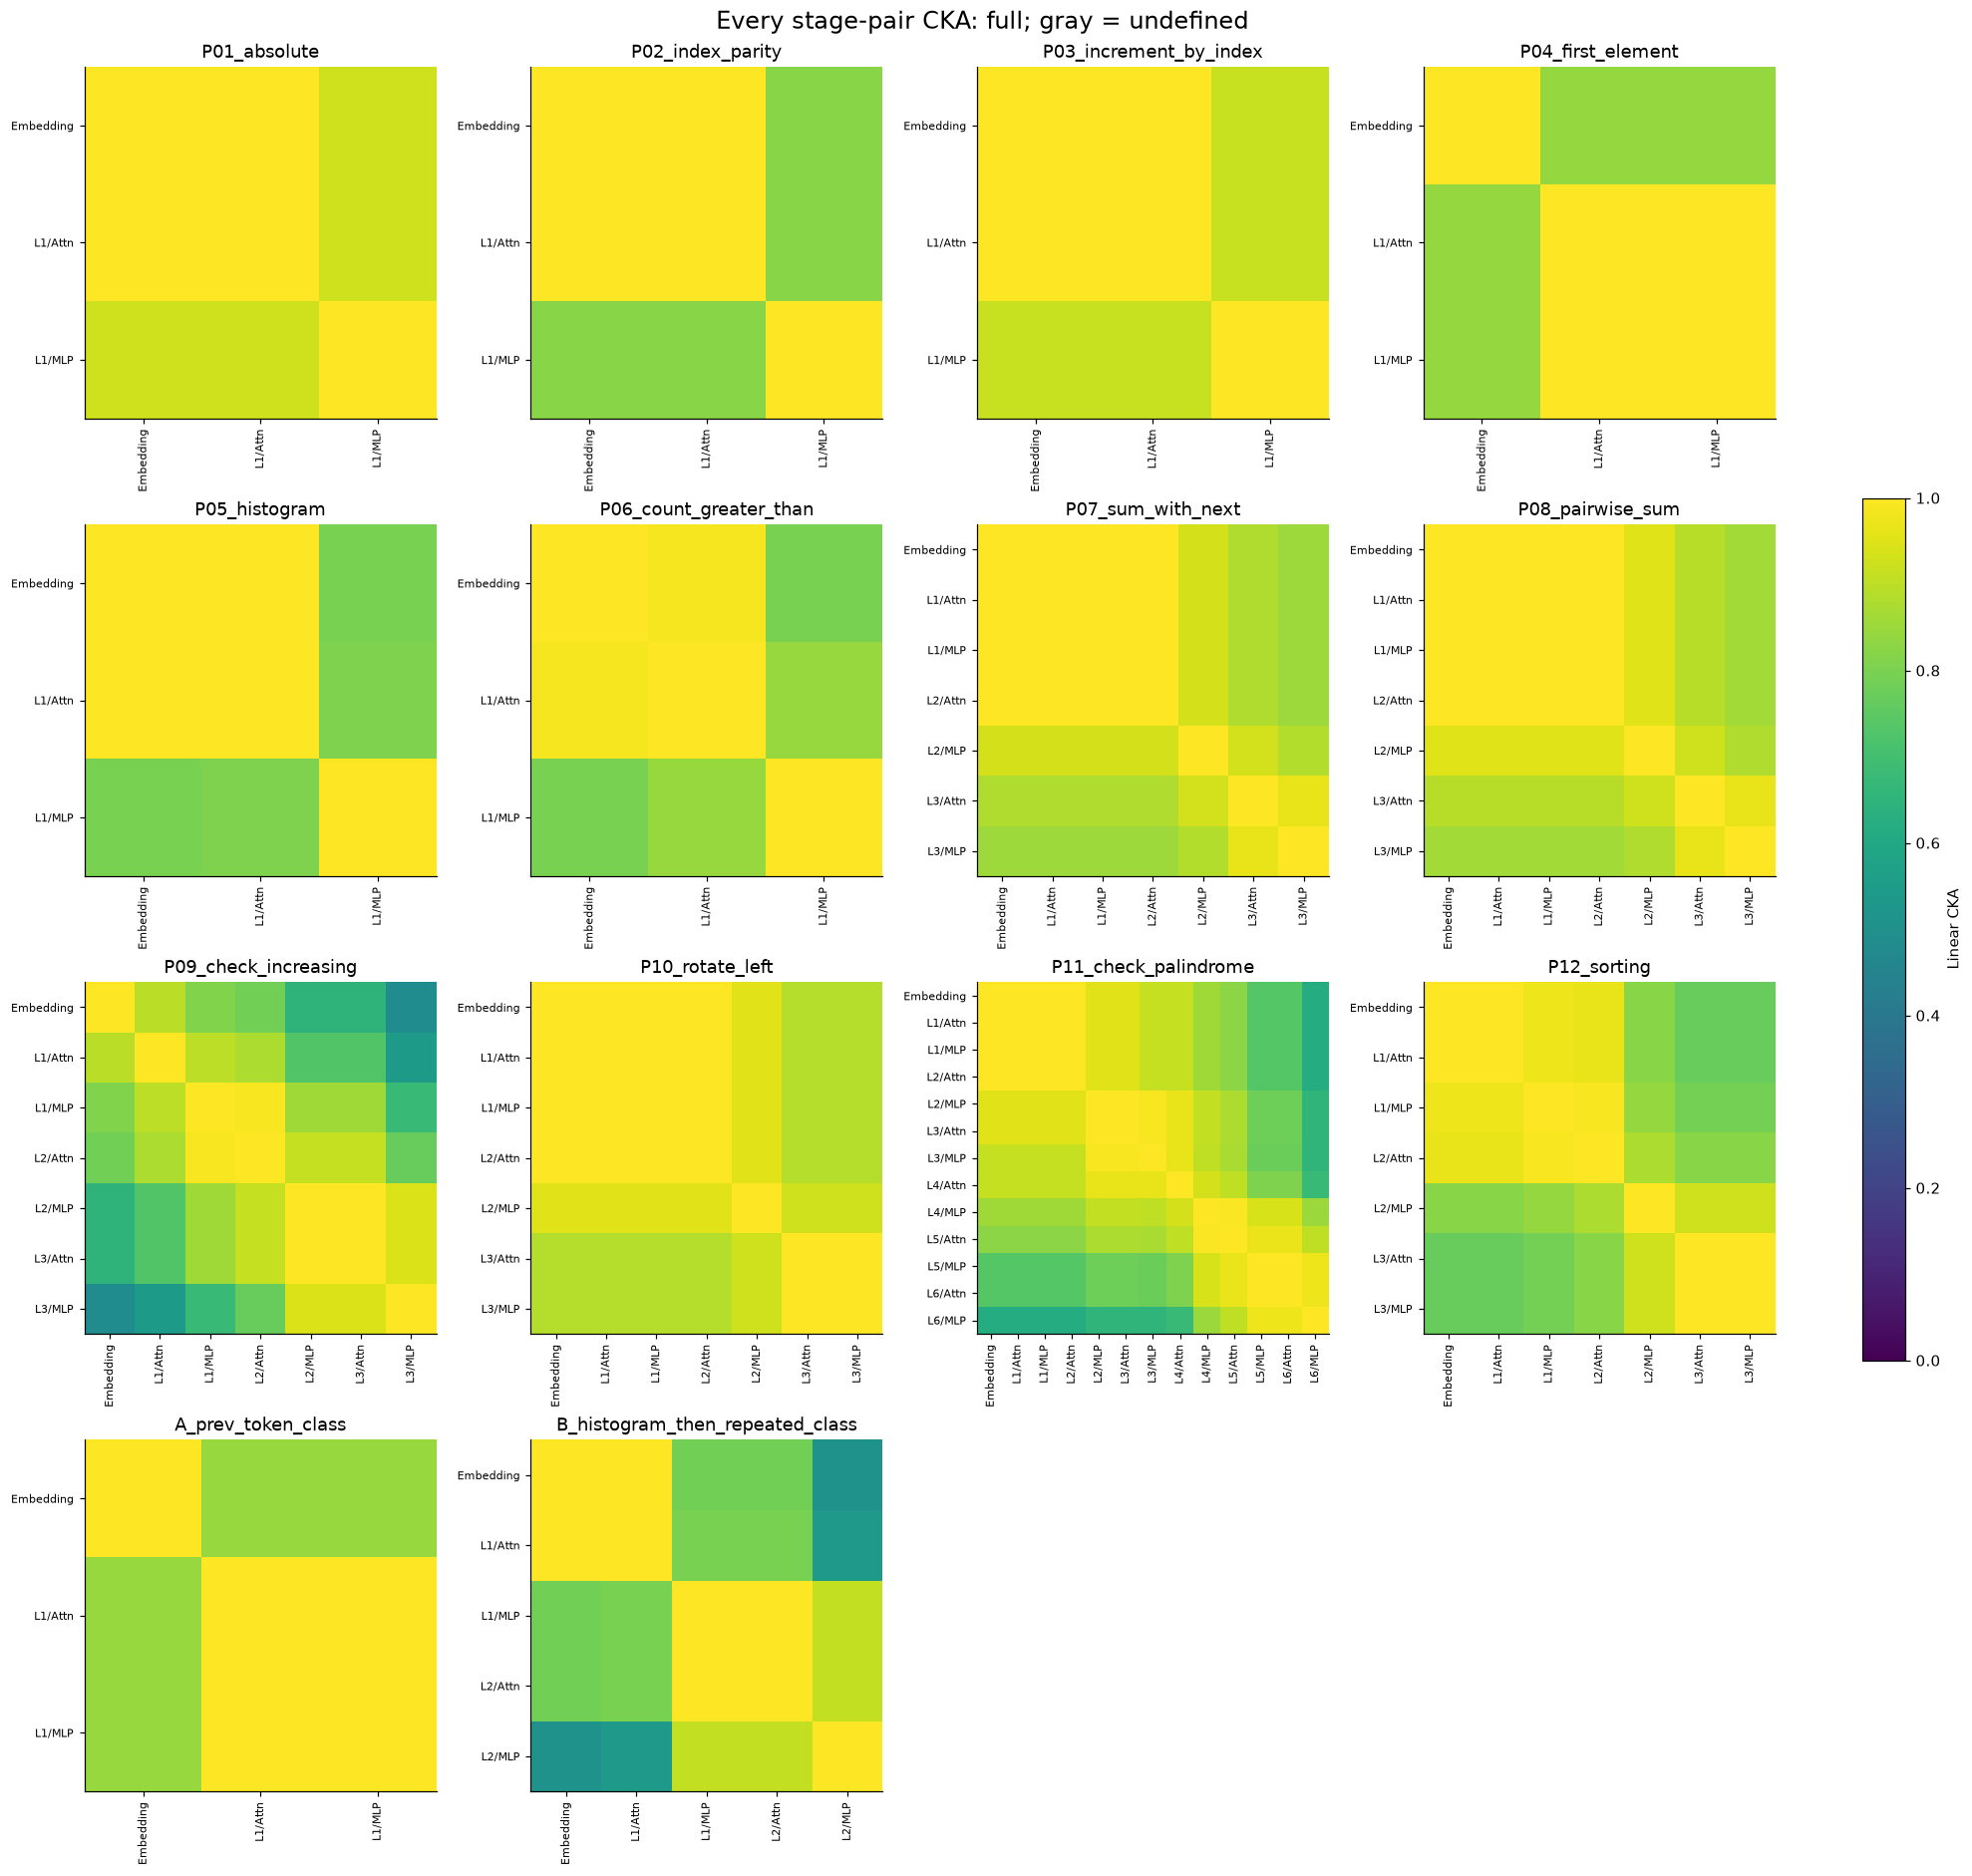

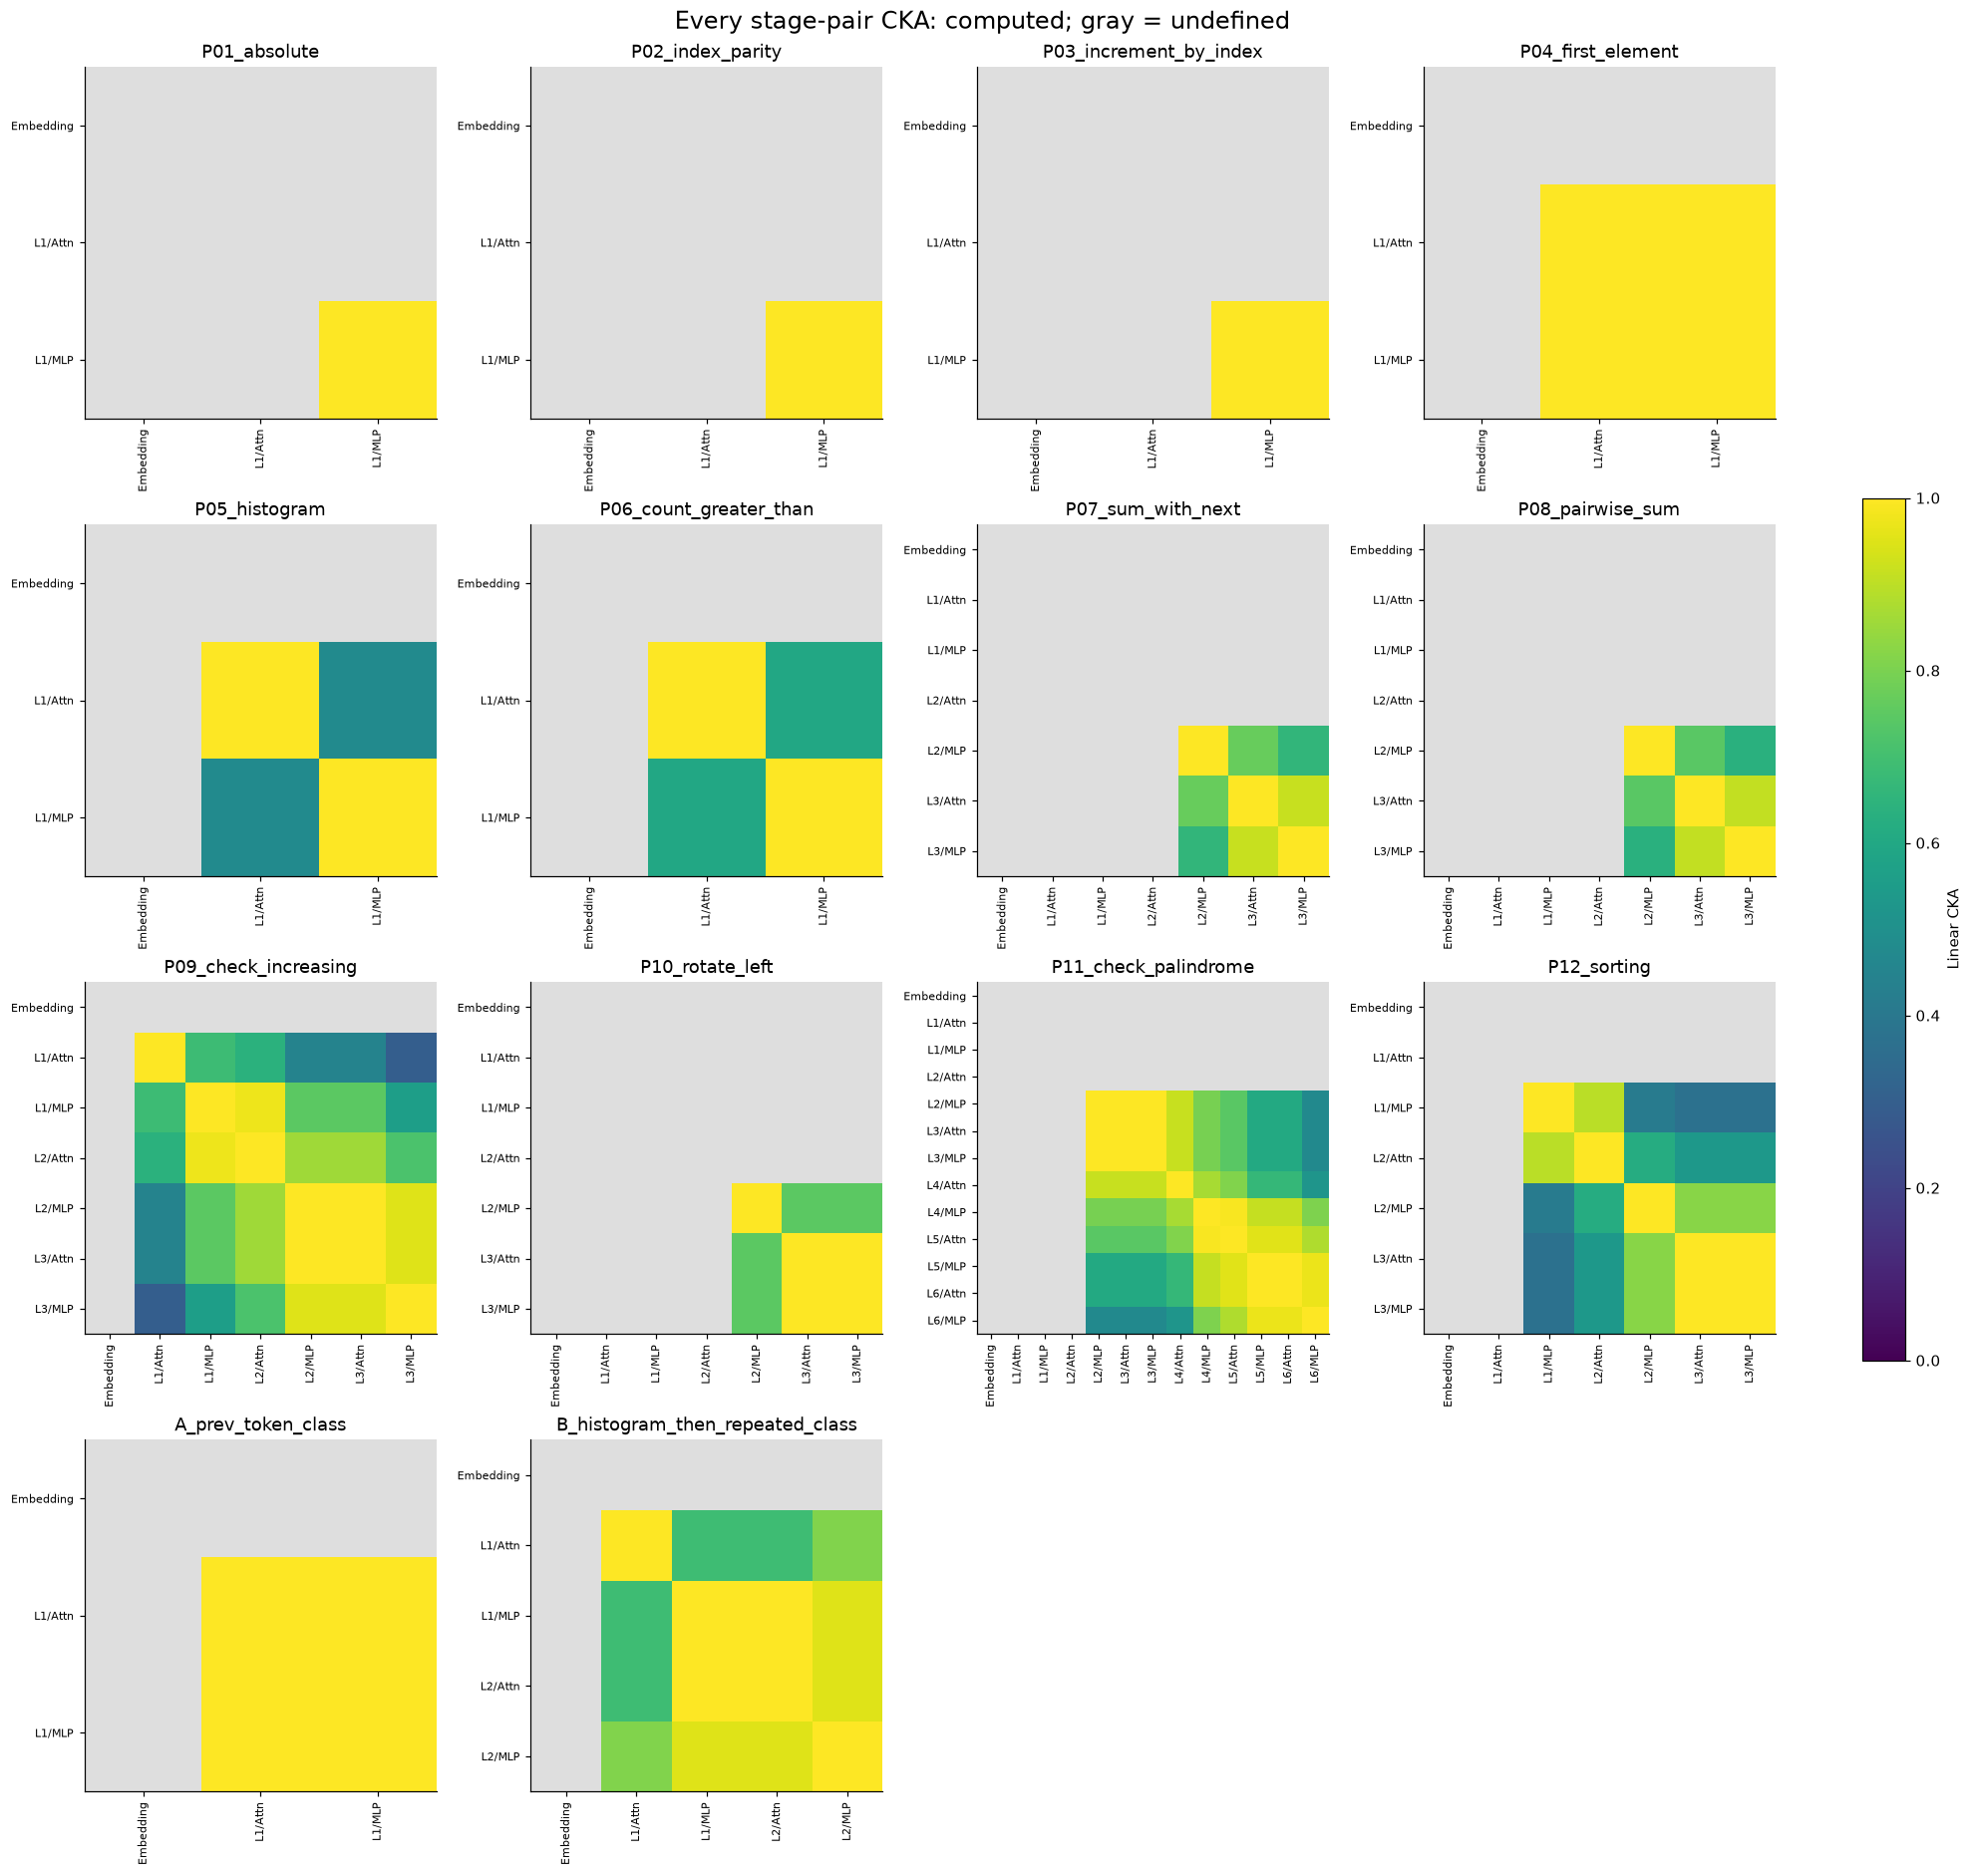

In [11]:
def cka_gallery(profiles, view, figure_dir):
    fig, axes = plt.subplots(
        (len(profiles) + 3) // 4,
        4,
        figsize=(18, 17),
        squeeze=False,
        constrained_layout=True,
    )
    for ax, (name, views) in zip(axes.flat, profiles.items()):
        image = cka_image(ax, views[view]["cka"], list(views[view]["pca"]), name)
    for ax in list(axes.flat)[len(profiles) :]:
        ax.axis("off")
    fig.colorbar(image, ax=list(axes.flat), shrink=0.5, label="Linear CKA")
    fig.suptitle(f"Every stage-pair CKA: {view}; gray = undefined", fontsize=16)
    fig.savefig(figure_dir / f"cka_gallery_{view}.png", bbox_inches="tight")
    plt.show()


cka_gallery(analysis.profiles, "full", FIGURE_DIR)
cka_gallery(analysis.profiles, "computed", FIGURE_DIR)

## Inspect lanes and a target trajectory

Lane variance is measured across sampled target observations. The trajectory
follows one target through stages using a single PCA fitted to all stages.

In [12]:
def plot_lane_variance(data, program, figure_dir, view="computed", top=25):
    matrix, stages, labels = lane_variances(data, program, view, top)
    fig, ax = plt.subplots(figsize=(13, max(5, 0.28 * len(labels))))
    image = ax.imshow(matrix, aspect="auto", cmap="magma")
    ax.set(
        xticks=range(len(stages)),
        xticklabels=stages,
        yticks=range(len(labels)),
        yticklabels=labels,
        title=f"{program} | {view} | most variable lanes",
    )
    ax.tick_params(axis="x", rotation=45)
    fig.colorbar(image, ax=ax, label="Sample variance")
    fig.tight_layout()
    fig.savefig(figure_dir / f"lane_variance_{program}_{view}.png", bbox_inches="tight")
    plt.show()


def plot_trajectory(data, program, figure_dir, probe_id=0, view="full"):
    xy, stages, common, target = trajectory_coordinates(data, program, probe_id, view)
    fig, ax = plt.subplots(figsize=(10, 7))
    (line,) = ax.plot(xy[:, 0], xy[:, 1], "o-", alpha=0.7, label="Selected target")
    ax.scatter(*xy[0], marker="s", s=80, color=line.get_color())
    ax.scatter(*xy[-1], marker="*", s=150, color=line.get_color())
    for index, stage in enumerate(stages):
        ax.annotate(
            stage, xy[index], fontsize=8, xytext=(5, 5), textcoords="offset points"
        )
    ratio = np.pad(
        common["explained_variance_ratio"], (0, max(0, 2 - len(common["eigenvalues"])))
    )
    ax.set(
        title=f"{program} | {view} | probe {probe_id}: {target.tokens}"
        f" | position {target.position} | class {target.target_class}; square = embedding, star = final",
        xlabel=f"Shared PC1 ({ratio[0]:.1%})",
        ylabel=f"Shared PC2 ({ratio[1]:.1%})",
    )
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(
        figure_dir / f"trajectories_{program}_{view}_probe{probe_id}.png",
        bbox_inches="tight",
    )
    plt.show()

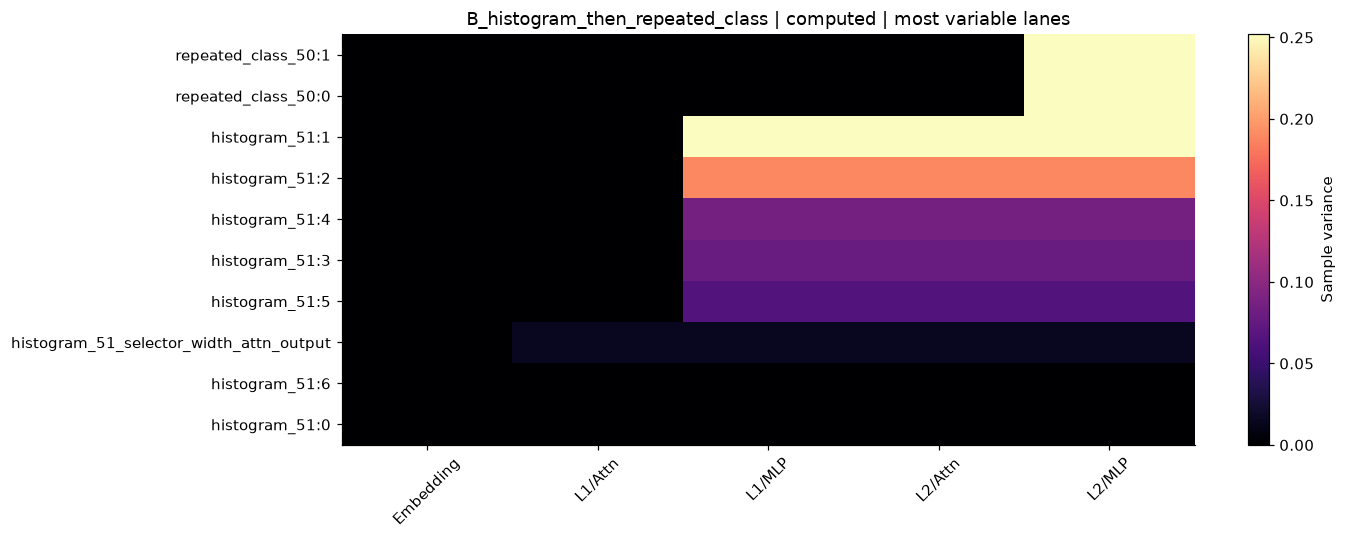

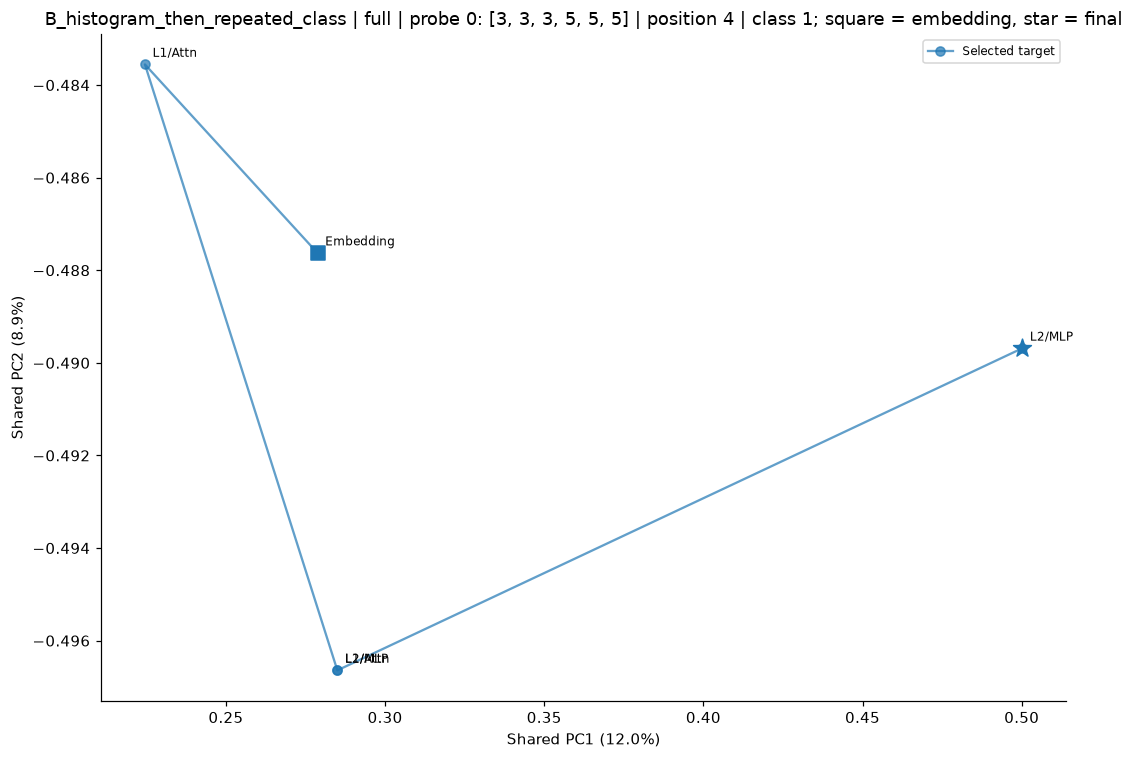

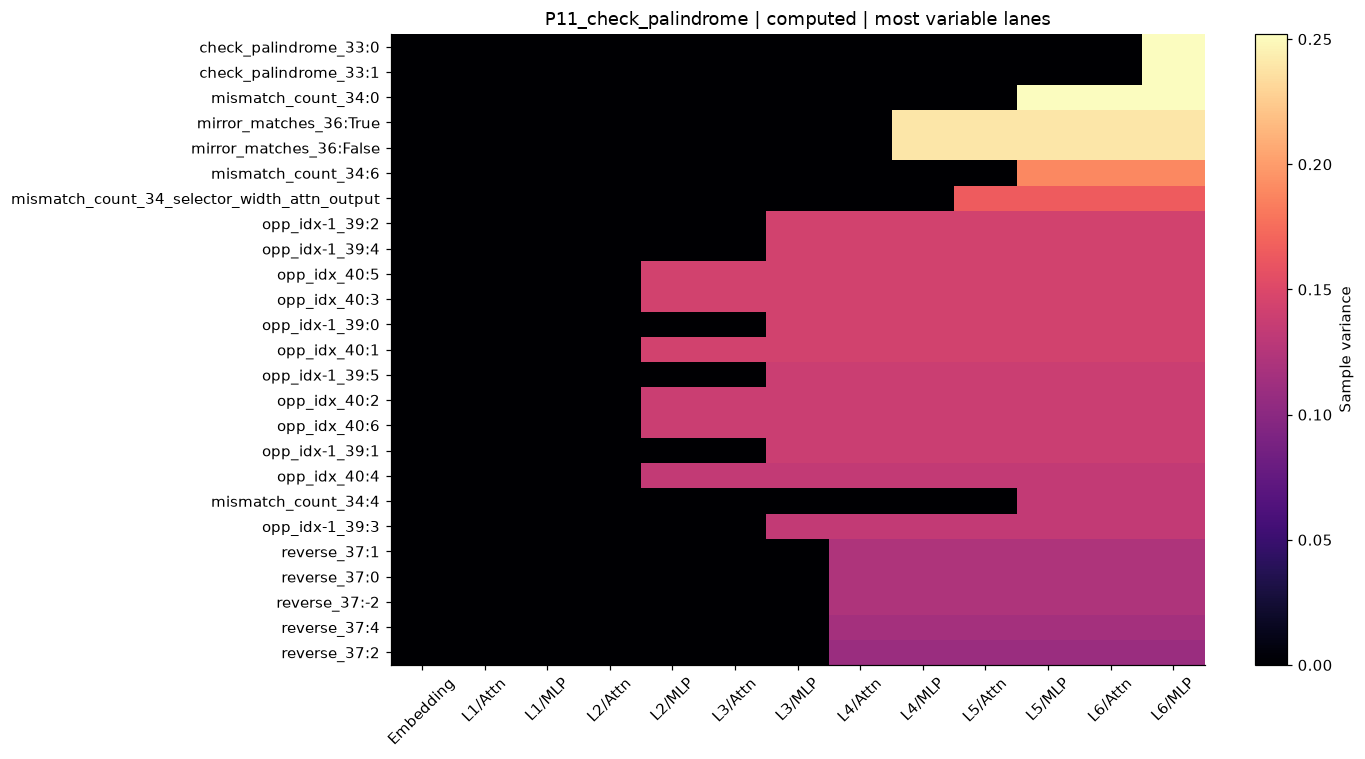

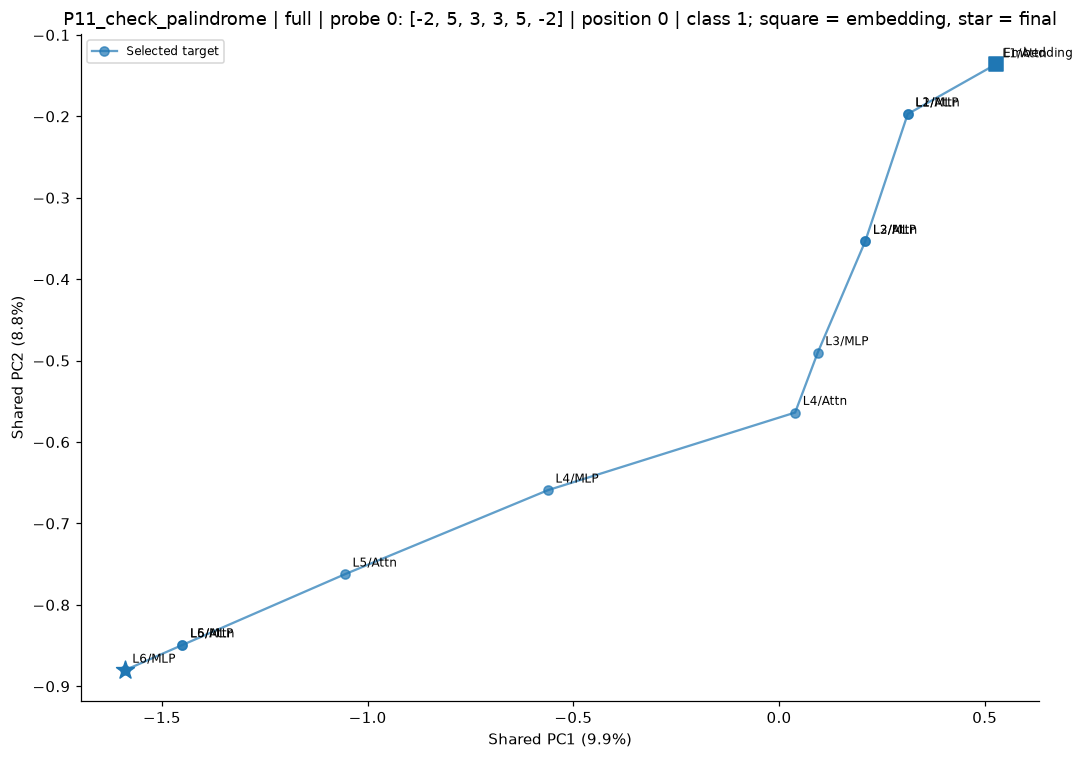

In [13]:
for name in ("B_histogram_then_repeated_class", "P11_check_palindrome"):
    plot_lane_variance(activations, name, FIGURE_DIR)
    plot_trajectory(activations, name, FIGURE_DIR)

## Export focused dashboards

The runner saved metrics, balance audit, probes, CKA tables, PCA arrays, and
a manifest before plotting. Each run directory contains its own figures.

In [14]:
for name in FOCUSED_PROGRAMS:
    for view in ("full", "computed"):
        fig = dashboard(activations, analysis.profiles, name, view)
        fig.savefig(FIGURE_DIR / f"dashboard_{name}_{view}.png", bbox_inches="tight")
        plt.close(fig)
print(f"Saved {len(list(FIGURE_DIR.glob('*.png')))} figures to {FIGURE_DIR}")

Saved 16 figures to /Users/raghul/RaspFormer/results/geometry/output_balanced_L6_seed42_n64_20261006T062123_fdb3cf7a/figures


These measurements describe this compiler revision, vocabulary, and one
seeded balanced probe design. Repeated targets are weighted observations,
not independent experimental trials. Cross-program values may reflect
different target distributions; CKA here compares stages within a program.